## Оптимизаторы Keras


1. Какие есть оптимизаторы?
2. Особенности SGD, Momentum, AdaGrad, RMSProp, Adam
3. Преимущества и недостатки

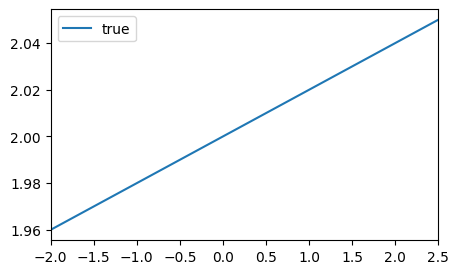

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


f = lambda x: 0.02 * x + 2
x = np.linspace(-2, 2.5, 10)
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.xlim([-2, 2.5])
plt.legend();

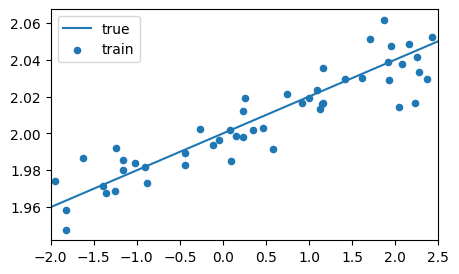

In [ ]:
n = 50
np.random.seed(9)
x_train = np.random.uniform(-2, 2.5, n)
y_train = f(x_train) + 0.01 * np.random.randn(n)
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train, s=20, label='train')
plt.xlim([-2, 2.5])
plt.legend();


Создадим сеть, она очень простая, состоит из одного слоя и одного нейрона.

<img src='https://drive.google.com/uc?id=1Qx71h2FmXS6uKHmhcIKtp49G5nqMncWK'>

In [ ]:
weight_1 = 0.5
weight_0 = -9

In [ ]:
pred = weight_0 + weight_1 * x_train

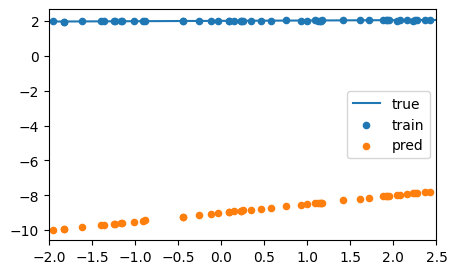

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train, s=20, label='train')
plt.scatter(x_train, pred,  s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

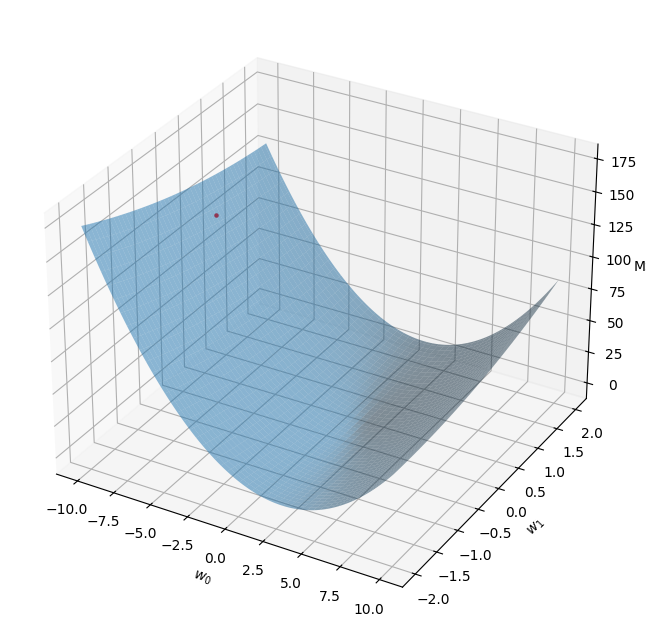

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()



$MSE = \frac{1}{n}\sum_{i=0}^n{(\text{y}_i-\text{y_pred}_i})^2 = \frac{1}{n}\sum_{i=0}^n{(\text{y}_i-(w_1\cdot X_i + w_0)})^2 = \frac{1}{n}\sum_{i=0}^n{(\text{y}_i-w_1\cdot X_i - w_0})^2$


gr_mserror - градиент функции MSE. Распишем его отдельно для коэффициента сдвига и коэффициента наклона:

Сдвиг:
$\frac{∂ MSE}{∂ w_0} = \frac{1 \cdot 2}{n}\sum({y_i -\text{y_pred}_i})\cdot -1$

Наклон:
$\frac{∂ MSE}{∂ w_1} = \frac{1 \cdot 2}{n}\sum({y_i -\text{y_pred}_i})\cdot -X$

In [ ]:
# функция градиента MSE
def gr_mserror(X, w0, w1, y):
    y_pred = w1 * X + w0
    return np.array([2/len(X)*np.sum((y - y_pred)) * (-1),
                     2/len(X)*np.sum((y - y_pred) * (-X))])

#### Алгоритм градиентного спуска


1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:

- $ w_{k} = w_{k-1} - \eta\nabla f(X, w_{k-1}) $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

for i in range(k):
    grad = gr_mserror(x_train, weights_0[-1], weights_1[-1], y_train)

    new_w_0 = weights_0[-1] - lr * grad[0]
    new_w_1 = weights_1[-1] - lr * grad[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

gd_weights_0 = weights_0.copy()
gd_weights_0

[-9,
 np.float64(-6.842853811984711),
 np.float64(-5.186920226846526),
 np.float64(-3.8877066397526194),
 np.float64(-2.8508643243530614),
 np.float64(-2.012715297174011),
 np.float64(-1.328761412918464),
 np.float64(-0.766827622695394),
 np.float64(-0.30290869717815705),
 np.float64(0.08139613206088747),
 np.float64(0.40050698988967376),
 np.float64(0.665921670949684),
 np.float64(0.886928461920637),
 np.float64(1.0711032273217804),
 np.float64(1.2246681255927316),
 np.float64(1.3527587706353987),
 np.float64(1.4596287175893683),
 np.float64(1.5488095233060373),
 np.float64(1.623238254057834),
 np.float64(1.6853604209274766),
 np.float64(1.7372138964686845),
 np.float64(1.7804978123746948),
 np.float64(1.8166294117663468),
 np.float64(1.8467911287091736),
 np.float64(1.8719696717090422),
 np.float64(1.8929885252819012),
 np.float64(1.9105350103958343),
 np.float64(1.9251828333402627),
 np.float64(1.9374108859364745),
 np.float64(1.947618926463698),
 np.float64(1.9561406623943012),
 np

In [ ]:
gd_weights_1 = weights_1.copy()
gd_weights_1

[0.5,
 np.float64(1.2870006637040499),
 np.float64(1.57495910519973),
 np.float64(1.6034755558648477),
 np.float64(1.5056389389965201),
 np.float64(1.3541259204955622),
 np.float64(1.187545573790087),
 np.float64(1.0254626826614335),
 np.float64(0.87693797615654),
 np.float64(0.7453603096206045),
 np.float64(0.6311616808414937),
 np.float64(0.5333265158331935),
 np.float64(0.45021688585665304),
 np.float64(0.3800118053900685),
 np.float64(0.320930659647655),
 np.float64(0.2713374501640942),
 np.float64(0.22978058441164156),
 np.float64(0.19499897335235877),
 np.float64(0.16591155188852186),
 np.float64(0.1415995913816614),
 np.float64(0.12128680183446901),
 np.float64(0.10431977451102366),
 np.float64(0.09014996359634575),
 np.float64(0.07831767309576142),
 np.float64(0.0684381313477716),
 np.float64(0.060189545766273805),
 np.float64(0.05330294703423182),
 np.float64(0.04755360542275573),
 np.float64(0.042753804474406014),
 np.float64(0.03874677362739681),
 np.float64(0.03540160314706

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

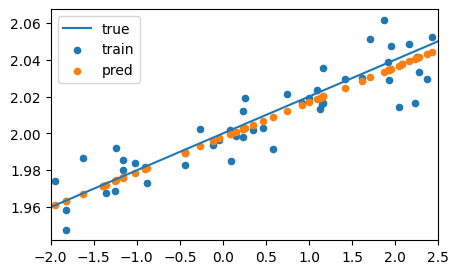

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train,  s=20, label='train')
plt.scatter(x_train, pred, s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

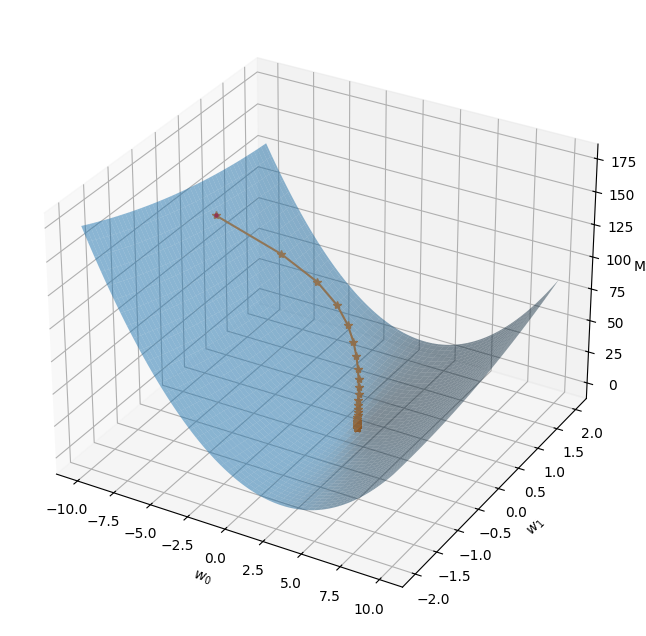

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(gd_weights_0)):
    mses.append(mse(gd_weights_0[i], gd_weights_1[i]))
ax.plot(gd_weights_0, gd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

### Стохастический градиентный спуск


#### Алгоритм стохастического градиентного спуска


1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:
- Выбираем случайный $x_i$ из X
- $ w_{k} = w_{k-1} - \eta\nabla f(x_i, w_{k-1}) $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

for i in range(k):
    idx = np.random.choice(len(x_train))
    grad = gr_mserror(x_train[[idx]], weights_0[-1], weights_1[-1], y_train[[idx]])

    new_w_0 = weights_0[-1] - lr * grad[0]
    new_w_1 = weights_1[-1] - lr * grad[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

sgd_weights_0 = weights_0.copy()
sgd_weights_0

[-9,
 np.float64(-6.815416410593148),
 np.float64(-4.980536379756948),
 np.float64(-3.5866032980529265),
 np.float64(-3.002447160986093),
 np.float64(-1.747323831322639),
 np.float64(-0.16336222495578712),
 np.float64(0.49069109347250706),
 np.float64(0.8130549934190352),
 np.float64(0.9633131257256021),
 np.float64(1.418790076701028),
 np.float64(1.6210752876881278),
 np.float64(1.768515873589087),
 np.float64(1.788742795866886),
 np.float64(1.7815400363102492),
 np.float64(1.8272051585625677),
 np.float64(1.8449508043395622),
 np.float64(1.8203504360142844),
 np.float64(1.8723796944485807),
 np.float64(1.8946447741692718),
 np.float64(1.9257743212086396),
 np.float64(1.9312552234392577),
 np.float64(1.945102728671552),
 np.float64(1.9503836360570612),
 np.float64(1.951627881458415),
 np.float64(1.9610808761710554),
 np.float64(1.9616511522898903),
 np.float64(1.9671228475706528),
 np.float64(1.96975907699054),
 np.float64(1.9641764633380803),
 np.float64(1.9807404648249591),
 np.floa

In [1]:
sgd_weights_1 = weights_1.copy()
sgd_weights_1

NameError: name 'weights_1' is not defined

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

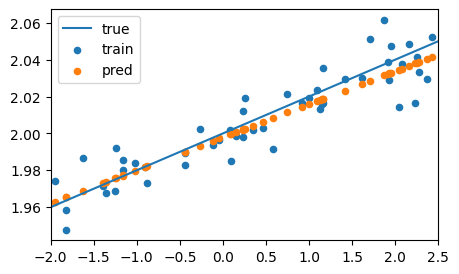

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train,  s=20,label='train')
plt.scatter(x_train, pred,  s=20,label='pred')
plt.xlim([-2, 2.5])
plt.legend();

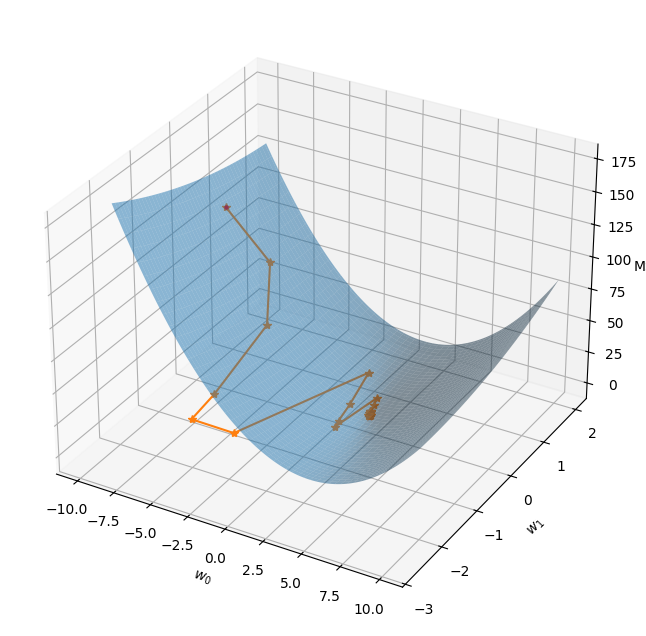

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(sgd_weights_0)):
    mses.append(mse(sgd_weights_0[i], sgd_weights_1[i]))
ax.plot(sgd_weights_0, sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

### Mini-Batch стохастический градиентный спуск

#### Алгоритм mini-batch стохастического градиентного спуска


1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:
- Выбираем случайные $x_i$ из X
- $ w_{k} = w_{k-1} - \eta\nabla f(x_i, w_{k-1}) $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1
amount = 10

weights_0, weights_1 = [weight_0], [weight_1]

for i in range(k):
    idx = np.random.choice(len(x_train), size=amount, replace=False)
    grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

    new_w_0 = weights_0[-1] - lr * grad[0]
    new_w_1 = weights_1[-1] - lr * grad[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

mb_sgd_weights_0 = weights_0.copy()
mb_sgd_weights_0

[-9,
 np.float64(-6.8631444974880935),
 np.float64(-5.243532234948031),
 np.float64(-3.964728683106543),
 np.float64(-2.761860290490796),
 np.float64(-1.9602405553175857),
 np.float64(-1.2614713382579539),
 np.float64(-0.7051494542787037),
 np.float64(-0.19130826145581192),
 np.float64(0.19735493655901348),
 np.float64(0.4540554872330744),
 np.float64(0.6954939923074622),
 np.float64(0.8835714149963764),
 np.float64(1.0821488249225226),
 np.float64(1.2715886813242168),
 np.float64(1.4094460803378102),
 np.float64(1.5009043928667811),
 np.float64(1.5824925765190607),
 np.float64(1.6626290845385507),
 np.float64(1.70463655505107),
 np.float64(1.7593113901446469),
 np.float64(1.8011504276870667),
 np.float64(1.8351090976818951),
 np.float64(1.8661914272992615),
 np.float64(1.8827243218591394),
 np.float64(1.8994988561775148),
 np.float64(1.9206850461982232),
 np.float64(1.9361346260244483),
 np.float64(1.9475967012787039),
 np.float64(1.9540227080228576),
 np.float64(1.9618861035243298),


In [ ]:
mb_sgd_weights_1 = weights_1.copy()
mb_sgd_weights_1

[0.5,
 np.float64(1.7246898086829847),
 np.float64(1.8056945571548562),
 np.float64(1.4759660011336715),
 np.float64(0.886515113634535),
 np.float64(1.2686793523927706),
 np.float64(1.0185716918578627),
 np.float64(0.8483567745159718),
 np.float64(0.6578165049752246),
 np.float64(0.6745992441640802),
 np.float64(0.6728158989669826),
 np.float64(0.5862939750549395),
 np.float64(0.4646264444928448),
 np.float64(0.36896555329415204),
 np.float64(0.23081973094765385),
 np.float64(0.1740570282212759),
 np.float64(0.2191683792369032),
 np.float64(0.17587710234306747),
 np.float64(0.13478559202490523),
 np.float64(0.14882521450432554),
 np.float64(0.10185951769524165),
 np.float64(0.09260767126628092),
 np.float64(0.08344085064567047),
 np.float64(0.0684160306793663),
 np.float64(0.0732082025007851),
 np.float64(0.06179484804089026),
 np.float64(0.044584214228515745),
 np.float64(0.03506409078807804),
 np.float64(0.030187867876028424),
 np.float64(0.03786077062733323),
 np.float64(0.033328915

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

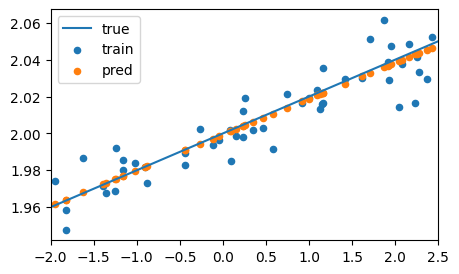

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train,  s=20, label='train')
plt.scatter(x_train, pred, s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

<Figure size 500x300 with 0 Axes>

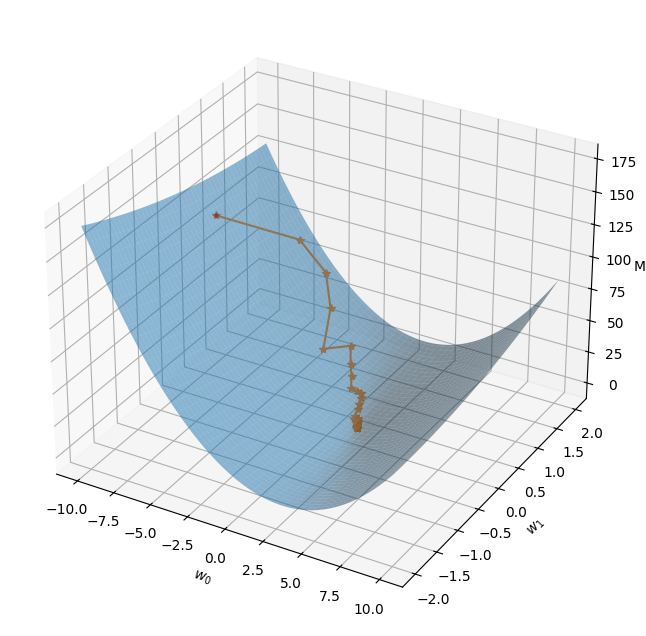

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D

plt.figure(figsize = (5,3))
def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(mb_sgd_weights_0)):
    mses.append(mse(mb_sgd_weights_0[i], mb_sgd_weights_1[i]))
ax.plot(mb_sgd_weights_0, mb_sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

<img src='https://ml-explained.com/_ipx/sizes_xs:320px%20md:768px%20lg:1024px,w_1536,f_png/articles/gradient-descent-explained/variations_comparison.png'>

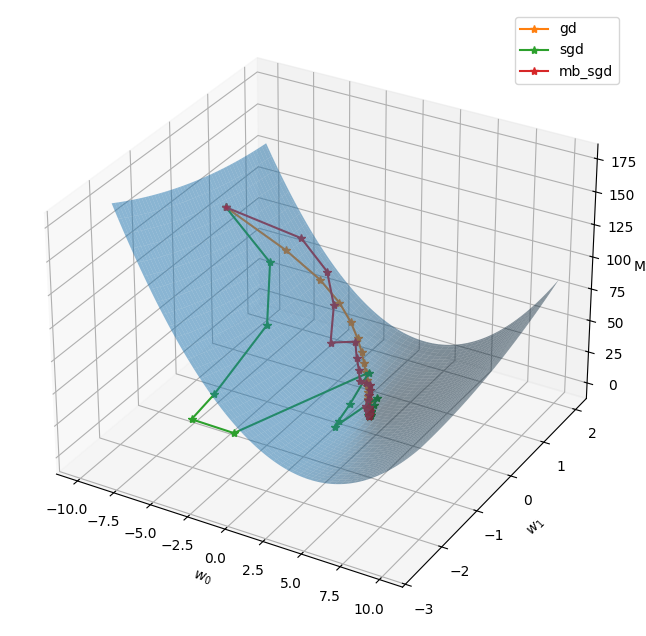

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(gd_weights_0)):
    mses.append(mse(gd_weights_0[i], gd_weights_1[i]))
ax.plot(gd_weights_0, gd_weights_1, mses, marker='*', label='gd')

mses = []
for i in range(len(sgd_weights_0)):
    mses.append(mse(sgd_weights_0[i], sgd_weights_1[i]))
ax.plot(sgd_weights_0, sgd_weights_1, mses, marker='*', label='sgd')

mses = []
for i in range(len(mb_sgd_weights_0)):
    mses.append(mse(mb_sgd_weights_0[i], mb_sgd_weights_1[i]))
ax.plot(mb_sgd_weights_0, mb_sgd_weights_1, mses, marker='*', label='mb_sgd')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.legend()
plt.show()

### Стохастический градиентный спуск + Momentum



<img src='https://drive.google.com/uc?export=view&id=1JMoY1y1oZUtiicvCuhxhliiLBLoNl7bA'>

Правило обновления весов w с градиентом g, когда импульс == 0:

$w^{k} = w^{k-1} - \eta * {\nabla Q(w^{k-1}, X)}$

Правило обновления весов w с градиентом g, когда импульс > 0:

$velocity = momentum * velocity - \eta * {\nabla Q(w^{k-1}, X)}$<br>
$w^{k} = w^{k-1} + velocity$

<img src='https://drive.google.com/uc?export=view&id=1h0u3hNo2cjDRoq0FVdXIScgRo6Iq687y'>

Засчет добавления импульса получается сглаживание оптимизации.

|$t_1$|$t_2$|..|$t_n$|
|--|--|--|--|
|$g_1$|$g_2$|..|$g_n$|

$\gamma = 0.5$

$v_1 = g_1$<br>
$v_2 = \gamma * v_1 + g_2 = 0.5 * g_1 + g_2$<br>
$v_3 = \gamma * v_2 + g_3 = \gamma (\gamma * v_1 + g_2) + g_3 = \gamma^2 * g_1 + \gamma * g_2 + g_3 = 0.25 * g_1 + 0.5 * g_2 + g_3$<br>


#### Алгоритм

1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:

- Выбираем случайные $x_i$ из X
- $velocity = momentum * velocity - \eta\nabla f(x_i, w_{k-1}) $

- $ w_{k} = w_{k-1} +  velocity $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

velocity = [0, 0]
momentum = 0.5
for i in range(k):
    idx = np.random.choice(len(x_train), size=amount, replace=False)
    grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

    velocity[0] = momentum * velocity[0] - lr * grad[0]
    velocity[1] = momentum * velocity[1] - lr * grad[1]

    new_w_0 = weights_0[-1] + velocity[0]
    new_w_1 = weights_1[-1] + velocity[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

momentum_sgd_weights_0 = weights_0.copy()
momentum_sgd_weights_0

[-9,
 np.float64(-6.80285136109089),
 np.float64(-3.9715915774580517),
 np.float64(-1.417504885563678),
 np.float64(0.3465286892411563),
 np.float64(1.4512964697568411),
 np.float64(2.125852394758322),
 np.float64(2.3937708226452443),
 np.float64(2.45038378575563),
 np.float64(2.4002146678710354),
 np.float64(2.327413294780666),
 np.float64(2.241675262348407),
 np.float64(2.160083930519824),
 np.float64(2.083319928150862),
 np.float64(2.0258768999052634),
 np.float64(1.9905053836829067),
 np.float64(1.9667361981046803),
 np.float64(1.9598221093015065),
 np.float64(1.9635721447012142),
 np.float64(1.974223700360884),
 np.float64(1.985603309484002),
 np.float64(1.9940891057665764),
 np.float64(1.9993422120413833),
 np.float64(2.0014724400912556),
 np.float64(2.001862689754177),
 np.float64(2.001845318247777),
 np.float64(2.001608318552937),
 np.float64(2.000392954356415),
 np.float64(1.9992092827544294),
 np.float64(1.99855265837311),
 np.float64(1.9983659689574171),
 np.float64(1.999002

In [ ]:
momentum_sgd_weights_1 = weights_1.copy()
momentum_sgd_weights_1

[0.5,
 np.float64(0.4672498718037054),
 np.float64(0.9018523191177299),
 np.float64(1.264985861582988),
 np.float64(1.2688048210174367),
 np.float64(1.0366098412983347),
 np.float64(0.4635191888457091),
 np.float64(-0.006671446130697367),
 np.float64(-0.2522792197845646),
 np.float64(-0.33454142798701053),
 np.float64(-0.2728555896999175),
 np.float64(-0.15280727161966903),
 np.float64(-0.04515048032694498),
 np.float64(0.0428326883778332),
 np.float64(0.07229927302111),
 np.float64(0.06701849638696215),
 np.float64(0.04365330846446977),
 np.float64(0.020763894150583787),
 np.float64(0.008860329849622942),
 np.float64(0.011017307708050407),
 np.float64(0.018708565580399295),
 np.float64(0.022096916464598732),
 np.float64(0.02216320739709747),
 np.float64(0.021170060897334444),
 np.float64(0.01809667157632993),
 np.float64(0.01665491004942651),
 np.float64(0.017401189146869448),
 np.float64(0.0179324730970616),
 np.float64(0.017919534915551982),
 np.float64(0.017842850187316205),
 np.fl

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

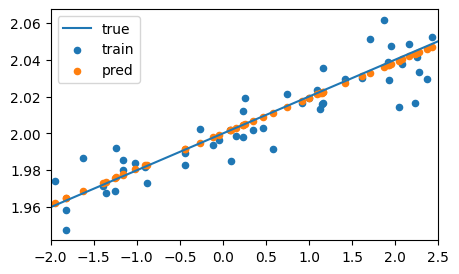

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train,  s=20, label='train')
plt.scatter(x_train, pred, s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

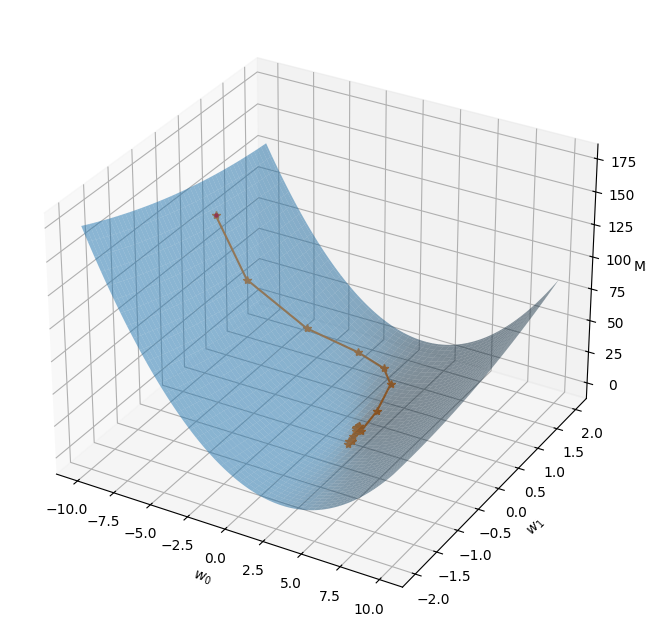

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(momentum_sgd_weights_0)):
    mses.append(mse(momentum_sgd_weights_0[i], momentum_sgd_weights_1[i]))
ax.plot(momentum_sgd_weights_0, momentum_sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

#### Эксперименты с моментумом

In [ ]:
k = 50
lr = 0.1


momentum_sgd_weights_0_exp = []
momentum_sgd_weights_1_exp = []
momentums = np.linspace(0, 0.8, 5)

for momentum in momentums:
    weights_0, weights_1 = [weight_0], [weight_1]
    velocity = [0, 0]

    for i in range(k):
        idx = np.random.choice(len(x_train), size=amount, replace=False)
        grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

        velocity[0] = momentum * velocity[0] - lr * grad[0]
        velocity[1] = momentum * velocity[1] - lr * grad[1]

        new_w_0 = weights_0[-1] + velocity[0]
        new_w_1 = weights_1[-1] + velocity[1]

        weights_0.append(new_w_0)
        weights_1.append(new_w_1)

    momentum_sgd_weights_0_exp.append(weights_0)
    momentum_sgd_weights_1_exp.append(weights_1)

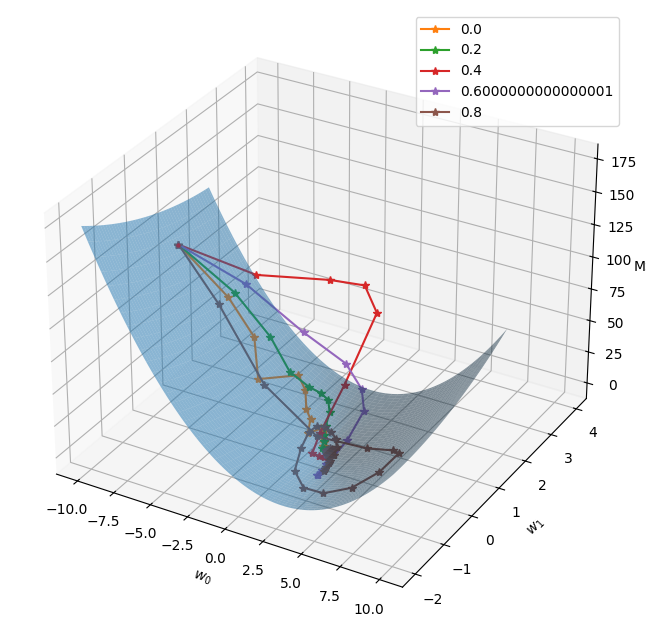

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

for j, (weights_0, weights_1) in enumerate(zip(momentum_sgd_weights_0_exp, momentum_sgd_weights_1_exp)):
    mses = []
    for i in range(len(weights_0)):
        mses.append(mse(weights_0[i], weights_1[i]))
    ax.plot(weights_0, weights_1, mses, marker='*', label=momentums[j])

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')
plt.legend()
plt.show()

In [ ]:
from keras.optimizers import SGD
SGD(momentum=0.5)

### AdaGrad (Adaptive Gradient Descent)


Gradient Descent:
$ w^{k} = w^{k-1} - \eta\nabla Q(w^{k-1}, X)$.

В Adagrad используются разные скорости обучения в зависимости от итерации:
<h3>$ w^{k} = w^{k-1} - \eta_{k}\nabla Q(w^{k-1}, X) $</h3>

<h2>$\eta_{k} = \frac{\eta}{\sqrt{\alpha_k + \epsilon}}$</h2>
где  $\epsilon$ - маленькое число, чтобы не было деления на ноль.
<h4>$\alpha_k = \sum_{i=0}^k{\nabla Q(w^{k-1}, X)}^2$</h4>

Обновление весов:

<h4>$ w^{k} = w^{k-1} - \eta_k\nabla Q(w^{k-1}, X)$</h4>

Получается, что когда $\alpha$ становится большим числом, то $\eta_{k}$ становится меньше, то есть с увеличением итерации - уменьшается скорость обучения, а значит и уменьшается скорость изменения весов.

Но есть одна очень большая проблема - чем больше итераций, тем $\alpha$ больше, скорость обучения меньше, это приведет к тому, что изменение весов может стать совсем незаметным. Но это решаемо с помощью RMSProp.

#### Алгоритм

1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:

- Выбираем случайные $x_i$ из X
- $\alpha_k = \sum{\nabla f(x_i, w_{k-1})^2}$
- $\eta_k = \frac{\eta}{\sqrt{\alpha_k + ϵ}} $
- $ w_{k} = w_{k-1} - \eta_k\nabla f(x_i, w_{k-1}) $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

alphas = [0, 0]# накопленные градиенты
eps = 10e-7
for i in range(k):
    idx = np.random.choice(len(x_train), size=amount, replace=False)
    grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

    alphas[0] += grad[0] ** 2
    alphas[1] += grad[1] ** 2

    lr_k_0 = lr / np.sqrt(alphas[0] + eps)
    lr_k_1 = lr / np.sqrt(alphas[1] + eps)

    new_w_0 = weights_0[-1] - lr_k_0 * grad[0]
    new_w_1 = weights_1[-1] - lr_k_1 * grad[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

adagrad_sgd_weights_0 = weights_0.copy()
adagrad_sgd_weights_0

[-9,
 np.float64(-8.900000000107323),
 np.float64(-8.830105038804792),
 np.float64(-8.772536946479853),
 np.float64(-8.723870167823577),
 np.float64(-8.68015800540215),
 np.float64(-8.639857575809245),
 np.float64(-8.60207993667154),
 np.float64(-8.56604209923212),
 np.float64(-8.532888414770307),
 np.float64(-8.502234495876197),
 np.float64(-8.472546865604428),
 np.float64(-8.443351943045192),
 np.float64(-8.415532448973023),
 np.float64(-8.388511545326747),
 np.float64(-8.363520452169364),
 np.float64(-8.33986742584015),
 np.float64(-8.315767192417033),
 np.float64(-8.293372594306636),
 np.float64(-8.271483179810106),
 np.float64(-8.24970415123146),
 np.float64(-8.229148440585039),
 np.float64(-8.209182899663718),
 np.float64(-8.189626106503965),
 np.float64(-8.17014712573621),
 np.float64(-8.151156465477216),
 np.float64(-8.132312638635728),
 np.float64(-8.114717893560574),
 np.float64(-8.09770446618925),
 np.float64(-8.080462445580917),
 np.float64(-8.06210791082659),
 np.float64(-

In [ ]:
adagrad_sgd_weights_1 = weights_1.copy()
adagrad_sgd_weights_1

[0.5,
 np.float64(0.5999999992846792),
 np.float64(0.6785296349037977),
 np.float64(0.70590920898568),
 np.float64(0.7720407200254398),
 np.float64(0.8183015173234012),
 np.float64(0.8456647058386646),
 np.float64(0.8523261895832334),
 np.float64(0.8254343314467771),
 np.float64(0.8282845503673938),
 np.float64(0.8555273289692694),
 np.float64(0.8638750153032584),
 np.float64(0.8372460090308415),
 np.float64(0.8253008588833727),
 np.float64(0.7908068777338849),
 np.float64(0.8054387386502599),
 np.float64(0.8353503318244463),
 np.float64(0.8300586221566927),
 np.float64(0.8603433497652337),
 np.float64(0.8839854913315442),
 np.float64(0.8887959915386974),
 np.float64(0.9152192035882606),
 np.float64(0.944762572814889),
 np.float64(0.9762678422902092),
 np.float64(0.9931498207274426),
 np.float64(1.0093863165221921),
 np.float64(1.013913276651369),
 np.float64(1.0480581991124729),
 np.float64(1.0856794367228237),
 np.float64(1.1029725573128442),
 np.float64(1.0920497935585474),
 np.floa

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

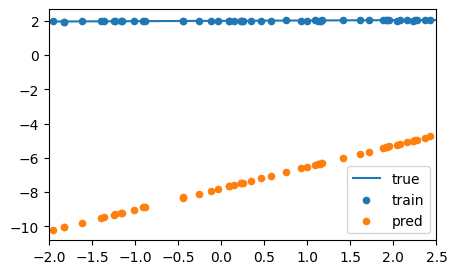

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train, s=20, label='train')
plt.scatter(x_train, pred, s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

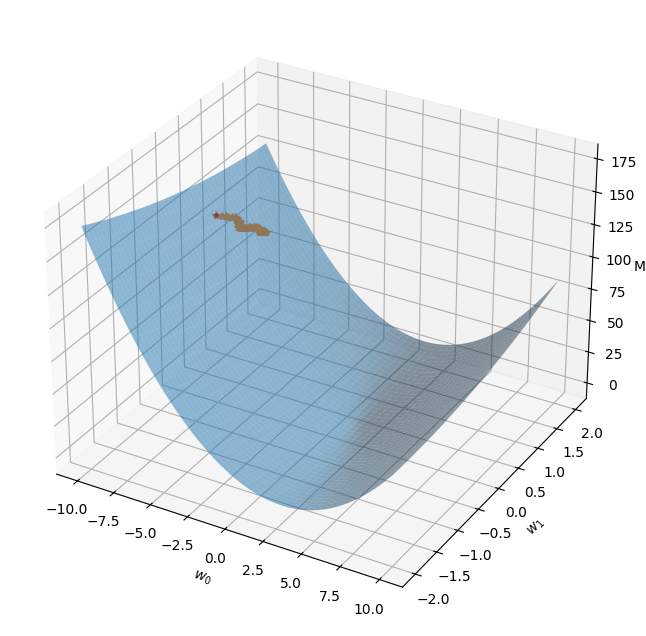

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(adagrad_sgd_weights_0)):
    mses.append(mse(adagrad_sgd_weights_0[i], adagrad_sgd_weights_1[i]))
ax.plot(adagrad_sgd_weights_0, adagrad_sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

In [ ]:
from keras.optimizers import Adagrad
Adagrad(learning_rate=0.001, initial_accumulator_value=0.1, epsilon=1e-07)

### RMS-Prop (Root Mean Square Propagation)

Этот оптимизатор исправляет проблему с неизменяемыми весами в Adagrad засчет введения ограничения на градиенты весов.

<h2>$\eta_{k} = \frac{\eta}{\sqrt{\alpha_{avg_k} + \epsilon}}$</h2>
где  $\epsilon$ - маленькое число, чтобы не было деления на ноль.

$\alpha_{avg_{0}} = 0$

<h4>$\alpha_{avg_k} = \rho * \alpha_{avg_{k-1}}+(1-\rho){\nabla Q(w^{k-1}, X)}^2$</h4>

Обновление весов:

<h4>$ w^{k} = w^{k-1} - \eta_k\nabla Q(w^{k-1}, X)$</h4>


#### Алгоритм

1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:

- Выбираем случайные $x_i$ из X
- $\alpha_{avg_k} = ρ ⋅ \alpha_{avg_{k-1}} + (1 - \rho) \nabla f(x_i, w_{k-1})^2$
- $\eta_k = \frac{\eta}{\sqrt{\alpha_{avg_k} + ϵ}} $
- $ w_{k} = w_{k-1} - \eta_k\nabla f(x_i, w_{k-1}) $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

alphas = [0, 0]
eps = 10e-7
rho = 0.9 #величина для взвешивания градиента
for i in range(k):
    idx = np.random.choice(len(x_train), size=amount, replace=False)
    grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

    alphas[0] = rho * alphas[0] + (1 - rho) * grad[0] ** 2
    alphas[1] = rho * alphas[1] + (1 - rho) * grad[1] ** 2

    lr_k_0 = lr / np.sqrt(alphas[0] + eps)
    lr_k_1 = lr / np.sqrt(alphas[1] + eps)

    new_w_0 = weights_0[-1] - lr_k_0 * grad[0]
    new_w_1 = weights_1[-1] - lr_k_1 * grad[1]

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

rmsprop_sgd_weights_0 = weights_0.copy()

In [ ]:
rmsprop_sgd_weights_1 = weights_1.copy()


In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

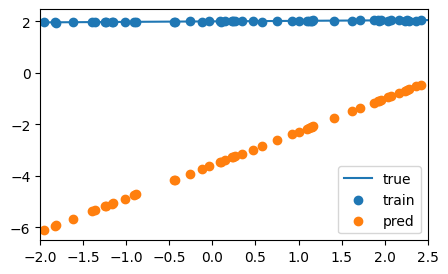

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train, label='train')
plt.scatter(x_train, pred, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

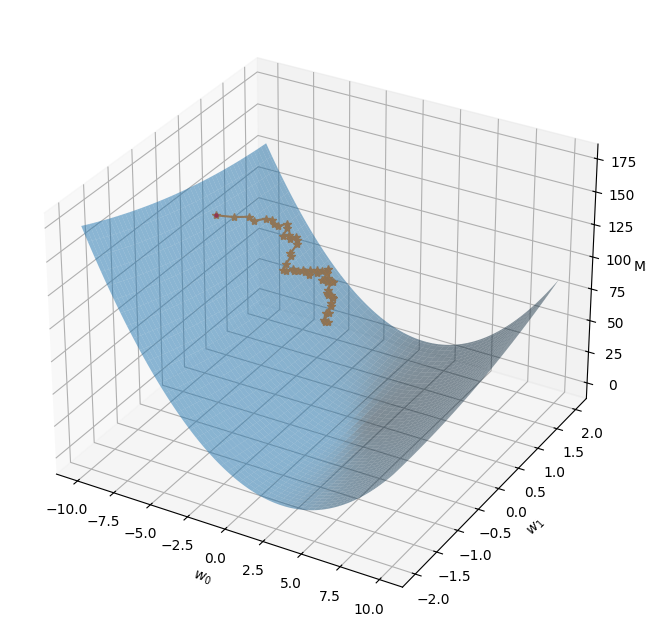

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(rmsprop_sgd_weights_0)):
    mses.append(mse(rmsprop_sgd_weights_0[i], rmsprop_sgd_weights_1[i]))
ax.plot(rmsprop_sgd_weights_0, rmsprop_sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

#### Эксперименты с rho

In [ ]:
k = 50
lr = 0.5


rmsprop_sgd_weights_0_exp = []
rmsprop_sgd_weights_1_exp = []
rhos = np.linspace(0.1, 0.9, 5)

for rho in rhos:
    weights_0, weights_1 = [weight_0], [weight_1]
    alphas = [0, 0]
    eps = 10e-7

    for i in range(k):
        idx = np.random.choice(len(x_train), size=amount, replace=False)
        grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

        alphas[0] = rho * alphas[0] + (1 - rho) * grad[0] ** 2
        alphas[1] = rho * alphas[1] + (1 - rho) * grad[1] ** 2

        lr_k_0 = lr / np.sqrt(alphas[0] + eps)
        lr_k_1 = lr / np.sqrt(alphas[1] + eps)

        new_w_0 = weights_0[-1] - lr_k_0 * grad[0]
        new_w_1 = weights_1[-1] - lr_k_1 * grad[1]

        weights_0.append(new_w_0)
        weights_1.append(new_w_1)

    rmsprop_sgd_weights_0_exp.append(weights_0)
    rmsprop_sgd_weights_1_exp.append(weights_1)

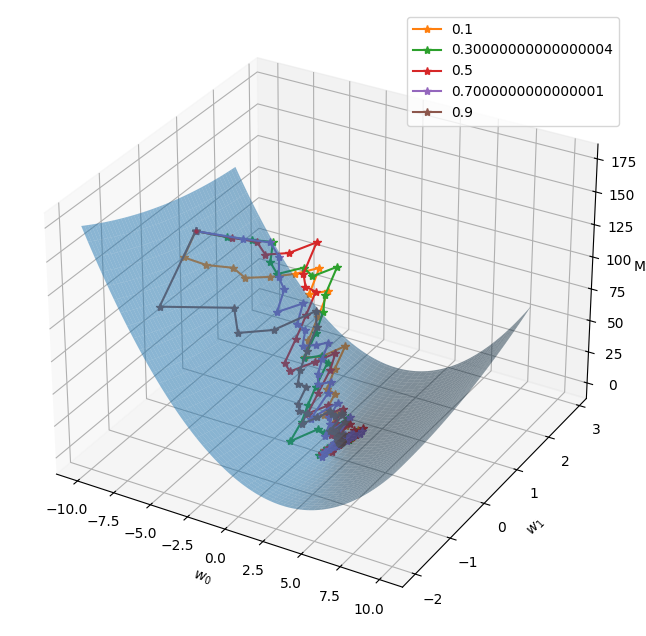

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

for j, (weights_0, weights_1) in enumerate(zip(rmsprop_sgd_weights_0_exp, rmsprop_sgd_weights_1_exp)):
    mses = []
    for i in range(len(weights_0)):
        mses.append(mse(weights_0[i], weights_1[i]))
    ax.plot(weights_0, weights_1, mses, marker='*', label=rhos[j])

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')
plt.legend()
plt.show()

In [ ]:
from keras.optimizers import RMSprop
RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-07)

### Adam (Adaptive Moment Estimation)

Здесь соединились два плюса предыдущих оптимизаторов:
1. Импульс (дает сглаживание оптимизации)
2. Постепенное уменьшение скорости обучения

<h4>$V_{k} = \beta_1 * V_{k-1} + g_k$</h4>

<h4>$\alpha_{avg_k} = \beta_2 * \alpha_{avg_{k-1}}+(1-\beta_2){\nabla Q(w^{k-1}, X)}^2$</h4>

Обновление весов:
<h4>$ w^{k} = w^{k-1} - \frac{\eta * V_k}{\sqrt{\alpha_{avg_k} + \epsilon}}$</h4>


#### Алгоритм

1. Инициализация начальной точки
2. Цикл по k = 1,2,3,...:

- Выбираем случайные $x_i$ из X
- $velocity = β_1 * velocity + \nabla f(x_i, w_{k-1}) $

- $\alpha_{avg_k} = β_2 ⋅ \alpha_{avg_{k-1}} + (1 - β_2) \nabla f(x_i, w_{k-1})^2$
- $ w_{k} = w_{k-1} - \frac{\eta ⋅ velocity}{\sqrt{\alpha_{avg_k} + ϵ}} $

- Если $||w_{k} - w_{k-1}|| < \epsilon$, то завершить.


In [ ]:
k = 50
lr = 0.1


weights_0, weights_1 = [weight_0], [weight_1]

alphas = [0, 0]
velocity = [0, 0]

eps = 10e-7

b1 = 0.6
b2 = 0.9
for i in range(k):
    idx = np.random.choice(len(x_train), size=amount, replace=False)
    grad = gr_mserror(x_train[idx], weights_0[-1], weights_1[-1], y_train[idx])

    velocity[0] = b1 * velocity[0] + grad[0]
    velocity[1] = b1 * velocity[1] + grad[1]

    alphas[0] = b2 * alphas[0] + (1 - b2) * grad[0] ** 2
    alphas[1] = b2 * alphas[1] + (1 - b2) * grad[1] ** 2

    new_w_0 = weights_0[-1] - (lr * velocity[0]) / np.sqrt(alphas[0] + eps)
    new_w_1 = weights_1[-1] - (lr * velocity[1]) / np.sqrt(alphas[1] + eps)

    weights_0.append(new_w_0)
    weights_1.append(new_w_1)

adam_sgd_weights_0 = weights_0.copy()
adam_sgd_weights_0

[-9,
 np.float64(-8.683772237271825),
 np.float64(-8.317769413790431),
 np.float64(-7.945746152679793),
 np.float64(-7.58223793256111),
 np.float64(-7.232299082460965),
 np.float64(-6.909265010756961),
 np.float64(-6.604153135754642),
 np.float64(-6.319064954074457),
 np.float64(-6.040508556091247),
 np.float64(-5.772494720340243),
 np.float64(-5.521421522228636),
 np.float64(-5.262207170485517),
 np.float64(-5.006187204652823),
 np.float64(-4.766822674044003),
 np.float64(-4.5520648298664),
 np.float64(-4.346792297486972),
 np.float64(-4.145042379116957),
 np.float64(-3.9690910853469292),
 np.float64(-3.759072464565765),
 np.float64(-3.558160690265171),
 np.float64(-3.335961784826991),
 np.float64(-3.116176908460312),
 np.float64(-2.8940961460531227),
 np.float64(-2.6840595476957176),
 np.float64(-2.4930674200824026),
 np.float64(-2.304273374686693),
 np.float64(-2.113188063632582),
 np.float64(-1.9147184765701),
 np.float64(-1.7158015141420722),
 np.float64(-1.5337278832929524),
 np.

In [ ]:
adam_sgd_weights_1 = weights_1.copy()
adam_sgd_weights_1

[0.5,
 np.float64(0.1837753922557363),
 np.float64(0.4256308020125479),
 np.float64(0.7644438527582124),
 np.float64(1.0493298003433291),
 np.float64(1.1552059265113053),
 np.float64(1.4583760152928735),
 np.float64(1.7535536773692249),
 np.float64(2.0427923345660557),
 np.float64(2.181109796903831),
 np.float64(2.1906669706134343),
 np.float64(2.253910695408802),
 np.float64(2.169459505538619),
 np.float64(2.0499512905376687),
 np.float64(2.006912709305151),
 np.float64(2.124475096590965),
 np.float64(2.2914822448710472),
 np.float64(2.3643670081330366),
 np.float64(2.478868911451754),
 np.float64(2.3241891344251093),
 np.float64(2.1711460884498632),
 np.float64(1.9529423137151716),
 np.float64(1.7656258698606622),
 np.float64(1.5598140549772486),
 np.float64(1.432641082084532),
 np.float64(1.4024245724374855),
 np.float64(1.381595584151891),
 np.float64(1.3524101904432784),
 np.float64(1.268828356042574),
 np.float64(1.1507230374617758),
 np.float64(1.0641252554896108),
 np.float64(1

In [ ]:
pred = weights_0[-1] + weights_1[-1] * x_train

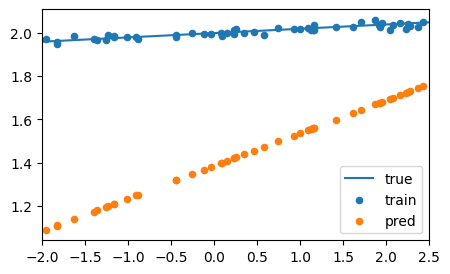

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(x, f(x), label='true')
plt.scatter(x_train, y_train,  s=20, label='train')
plt.scatter(x_train, pred,  s=20, label='pred')
plt.xlim([-2, 2.5])
plt.legend();

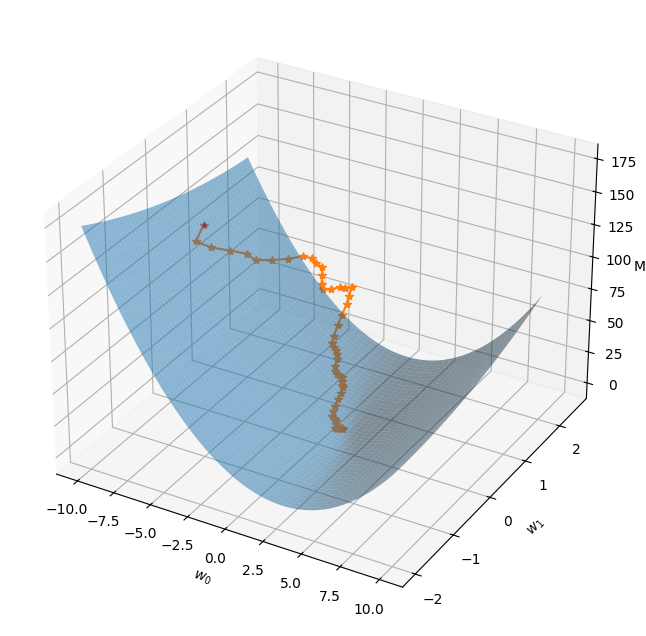

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def mse(w0, w1):
    y_pred = w1 * x_train + w0
    return np.mean((y_train - y_pred) ** 2)


coefs_a = np.linspace(-2, 2, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

zs = np.array([mse(i, j) for i, j in zip(np.ravel(w0), np.ravel(w1))])
Z = zs.reshape(w1.shape)

ax.plot_surface(w0, w1, Z, alpha=.5)
ax.scatter(weight_0, weight_1, mse(weight_0, weight_1), c='r', s=5)

mses = []
for i in range(len(adam_sgd_weights_0)):
    mses.append(mse(adam_sgd_weights_0[i], adam_sgd_weights_1[i]))
ax.plot(adam_sgd_weights_0, adam_sgd_weights_1, mses, marker='*')

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_1$')
ax.set_zlabel('MSE')

plt.show()

In [ ]:
from keras.optimizers import Adam
Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

## Пример на данных

Получение данных

Описание датасета:

- CRIM     per capita crime rate by town
- ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS    proportion of non-retail business acres per town
- CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX      nitric oxides concentration (parts per 10 million)
- RM       average number of rooms per dwelling
- AGE      proportion of owner-occupied units built prior to 1940
- DIS      weighted distances to five Boston employment centres
- RAD      index of accessibility to radial highways
- TAX      full-value property-tax rate per 10,000
- PTRATIO  pupil-teacher ratio by town
- B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT    % lower status of the population
- MEDV     Median value of owner-occupied homes in $1000's

In [ ]:
from keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

X_train.shape, X_test.shape

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((404, 13), (102, 13))

In [ ]:
X_train[:1]

array([[  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
         91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
         18.72   ]])

Масштабирование данных

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

mean, std

(array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
        5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
        9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
        1.27408168e+01]),
 array([9.22929073e+00, 2.37382770e+01, 6.80287253e+00, 2.40939633e-01,
        1.17147847e-01, 7.08908627e-01, 2.79060634e+01, 2.02770050e+00,
        8.68758849e+00, 1.66168506e+02, 2.19765689e+00, 9.39946015e+01,
        7.24556085e+00]))

In [ ]:
X_train -= mean
X_train /= std

X_test -= mean
X_test /= std

In [ ]:
X_train.mean(axis=0)

array([-1.01541438e-16,  1.09923072e-17,  1.74337992e-15, -1.26686340e-16,
       -5.25377321e-15,  6.41414864e-15,  2.98441140e-16,  4.94653823e-16,
        1.12671149e-17, -1.98136337e-16,  2.36686358e-14,  5.95679996e-15,
        6.13920356e-16])

In [ ]:
X_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Архитектура сети


Определение сети через класс Sequential и добавление слоев в него через add

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

### Обучение сети

In [ ]:
import keras
keras.utils.set_random_seed(1)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
model.layers[0].get_weights()[0][0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


array([-0.17600164,  0.2646938 ,  0.32016253, -0.11448252, -0.34217083,
       -0.28456724,  0.03290179, -0.3531145 ,  0.21653193, -0.15907353,
        0.10730779, -0.2749906 ,  0.08790419, -0.10920227,  0.02119857,
       -0.30589145, -0.14223927,  0.00555247,  0.33767045, -0.17586714,
       -0.2734608 , -0.08977506,  0.09206462,  0.30506545,  0.15165645,
       -0.19423014,  0.280748  , -0.17011668, -0.2351049 , -0.22945108,
       -0.30746546,  0.17588419], dtype=float32)

Epoch 1/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 490.3927 - mae: 19.9974 - val_loss: 406.4101 - val_mae: 18.1097
Epoch 2/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 328.5421 - mae: 15.9161 - val_loss: 231.2035 - val_mae: 12.5582
Epoch 3/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 155.0226 - mae: 9.5481 - val_loss: 31.5144 - val_mae: 3.9489
Epoch 4/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31.8743 - mae: 3.7540 - val_loss: 44.0017 - val_mae: 5.1669
Epoch 1/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 579.6334 - mae: 22.2252 - val_loss: 506.9121 - val_mae: 20.7910
Epoch 2/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 473.5247 - mae: 19.8687 - val_loss: 401.5875 - val_mae: 18.3222
Epoch 3/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 368.1351 - mae: 17.3563 - val_loss: 301.8370 - val_mae: 15.6429
Epoch 4/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 272.1653 - mae: 14.7334 - val_loss: 220.2551 - val_mae: 12.9902


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 450.4199 - mae: 18.8052 - val_loss: 71.6161 - val_mae: 6.7042
Epoch 2/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 51.1902 - mae: 5.3933 - val_loss: 31.5976 - val_mae: 4.4358
Epoch 3/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 23.4890 - mae: 3.5589 - val_loss: 27.8443 - val_mae: 4.0809
Epoch 4/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.6515 - mae: 3.1860 - val_loss: 26.3551 - val_mae: 3.8337


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 561.9049 - mae: 21.8110 - val_loss: 345.5344 - val_mae: 16.8299
Epoch 2/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 246.9804 - mae: 13.3990 - val_loss: 92.7519 - val_mae: 7.8410
Epoch 3/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 78.5162 - mae: 6.8579 - val_loss: 38.5136 - val_mae: 5.0588
Epoch 4/4
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 31.7635 - mae: 4.1980 - val_loss: 27.3439 - val_mae: 4.1713


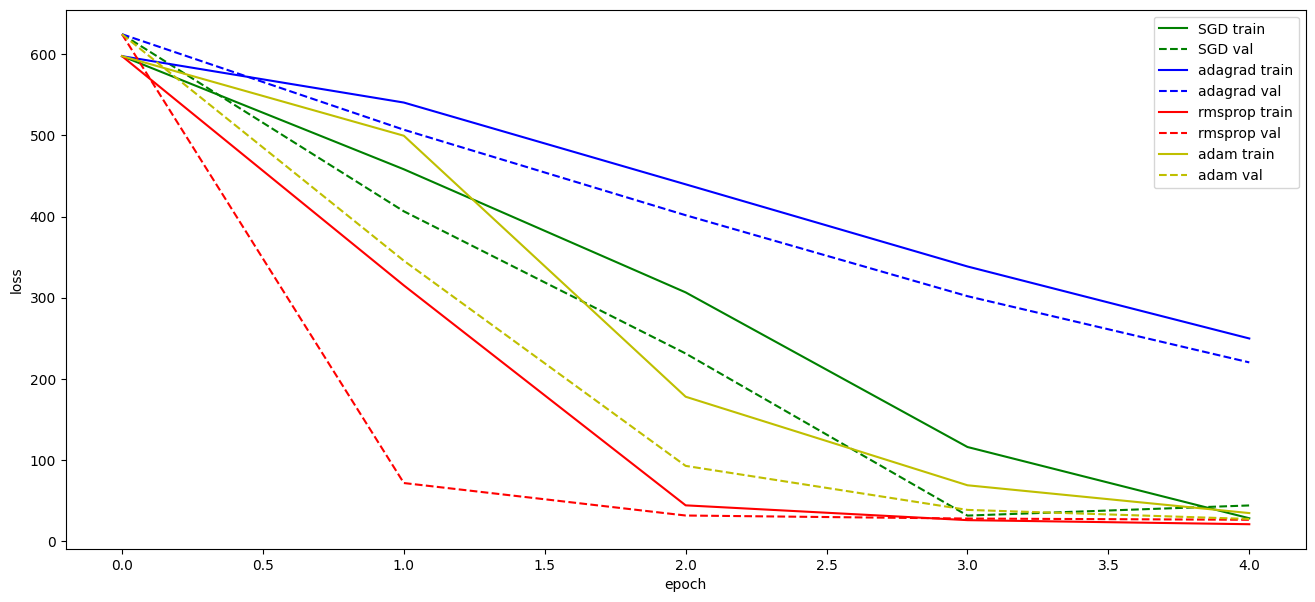

CPU times: user 7.88 s, sys: 396 ms, total: 8.27 s
Wall time: 8.62 s


In [ ]:
%%time

# будем сохранять модели в словарь
models = {}

plt.figure(figsize=(16, 7))
colors = ['g', 'b', 'r', 'y']

num_epochs = 4
batch_size = 32

# вектор для вывода результатов
epoch = np.arange(num_epochs+1)

# будем изменять оптимизаторы
for i, i_optim in enumerate([SGD(learning_rate=0.01),
                             Adagrad(learning_rate=0.01),
                             RMSprop(learning_rate=0.01),
                             Adam(learning_rate=0.01)]):

    # создаем рабочую модель  model с зафиксированными весами
    keras.utils.set_random_seed(1)

    model = Sequential()
    model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))

    # компилируем model с одним из оптимизаторов
    model.compile(optimizer=i_optim, loss='mse', metrics=['mae'])

    # вычисляем ошибку для model без обучения
    h0_train = model.evaluate(X_train, y_train, verbose=0)
    h0_val = model.evaluate(X_test, y_test, verbose=0)

    # проводим обучение модели
    h = model.fit(X_train, y_train,
                    epochs=num_epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    verbose=1)

    # записываем обученную модель в словарь
    models[i_optim.get_config()['name']] = model

    # картинки
    plt.plot(epoch, [h0_train[0]] + h.history['loss'], '-', c=colors[i],
             label=model.optimizer.get_config()['name'] + ' train')
    plt.plot(epoch, [h0_val[0]] + h.history['val_loss'], '--', c=colors[i],
             label=model.optimizer.get_config()['name'] + ' val')
    print('=' * 20)

plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## Summary


Вот мы и разобрались:
1. Какие есть оптимизаторы
2. Особенности SGD, Momentum, AdaGrad, RMSProp, Adam
3. Преимущества и недостатки

<table>
<tr>
<th>
Оптимизаторы
</th>

<th>
Плюсы
</th>

<th>
Минусы
</th>
</tr>

<tr>
<td>
Gradient Descent
</td>

<td>

        1. Легко реализовать
</td>

<td>

        1. Одна итерация длится долго
        2. Требователен к памяти
</td>
</tr>


<tr>
<td>
Stochastic Gradient Descent

</td>

<td>

        1. Много обновление весов
        2. Требует меньше памяти
        3. Можно использовать большие датасеты
        4. Случайность может помочь перепрыгнуть локальные минимумы

</td>

<td>

        1. Частые обновления весов могут вносит шум
        2. Случайность может увести не туда

</td>
</tr>

<tr>
<td>
SGD + Momentum

</td>

<td>

        1. Импульс сглаживает схождение
</td>

<td>

        1. Дополнительный параметр

</td>
</tr>

<tr>
<td>
AdaGrad
</td>

<td>

        1. Адаптивное изменение скорости обучения
    
</td>

<td>

        1. Скорость обучения может стать слишком маленькой
</td>
</tr>

<tr>
<td>
RMSProp
</td>

<td>

        1. Адаптивное изменение скорости обучения

</td>

<td>

        1. Может быть медленное схождение
</td>
</tr>

<tr>
<td>
Adam
</td>

<td>

        1. Адаптивное изменение скорости обучения
        2. Импульс сглаживает схождение
</td>

<td>

        1. Дополнительные параметры
</td>
</tr>

</table>
